# Vertex AI Sentiment Analysis - Complete Example

In [ ]:
# Setup: Install required packages if needed
import sys
import datasets
import transformers

✅ All packages already installed


In [78]:
import os
import sys
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import vertex_ai_utils as vai
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
plt.style.use('default')

In [79]:
# Google Cloud Configuration
PROJECT_ID = "noted-cortex-477800-b7"
BUCKET_NAME = "vertex-ai-sentiment-data-msml610"
LOCATION = "us-central1"

# Data paths
DATA_PATH = "Data/Tweets.csv"
PROCESSED_DATA_DIR = "Data/processed"

print(f"Project Configuration:")
print(f"  • Project ID: {PROJECT_ID}")
print(f"  • Bucket: {BUCKET_NAME}")
print(f"  • Location: {LOCATION}")

Project Configuration:
  • Project ID: noted-cortex-477800-b7
  • Bucket: vertex-ai-sentiment-data-msml610
  • Location: us-central1


In [80]:
# Load data
df = vai.load_twitter_data(DATA_PATH)

print(f"\nDataset shape: {df.shape}")
df.head()

Successfully loaded 14640 tweets from Data/Tweets.csv

Dataset shape: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &...",NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing about it,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [81]:
# Print comprehensive summary
vai.print_dataset_summary(df)

DATASET SUMMARY

 Basic Information:
Total Records: 14,640
Number of Columns: 15
Memory Usage: 9.87 MB

 Columns:
tweet_id                       - Type: int64      - Missing:      0 ( 0.00%)
airline_sentiment              - Type: object     - Missing:      0 ( 0.00%)
airline_sentiment_confidence   - Type: float64    - Missing:      0 ( 0.00%)
negativereason                 - Type: object     - Missing:  5,462 (37.31%)
negativereason_confidence      - Type: float64    - Missing:  4,118 (28.13%)
airline                        - Type: object     - Missing:      0 ( 0.00%)
airline_sentiment_gold         - Type: object     - Missing: 14,600 (99.73%)
name                           - Type: object     - Missing:      0 ( 0.00%)
negativereason_gold            - Type: object     - Missing: 14,608 (99.78%)
retweet_count                  - Type: int64      - Missing:      0 ( 0.00%)
text                           - Type: object     - Missing:      0 ( 0.00%)
tweet_coord                    - Type: 

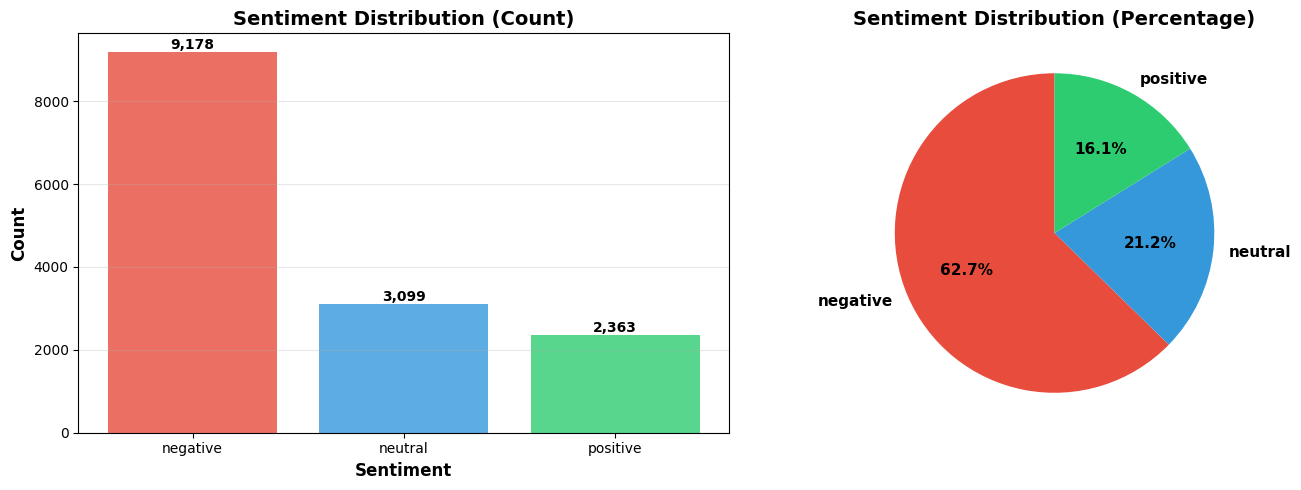

In [82]:
# Visualize sentiment distribution
vai.visualize_sentiment_distribution(df)

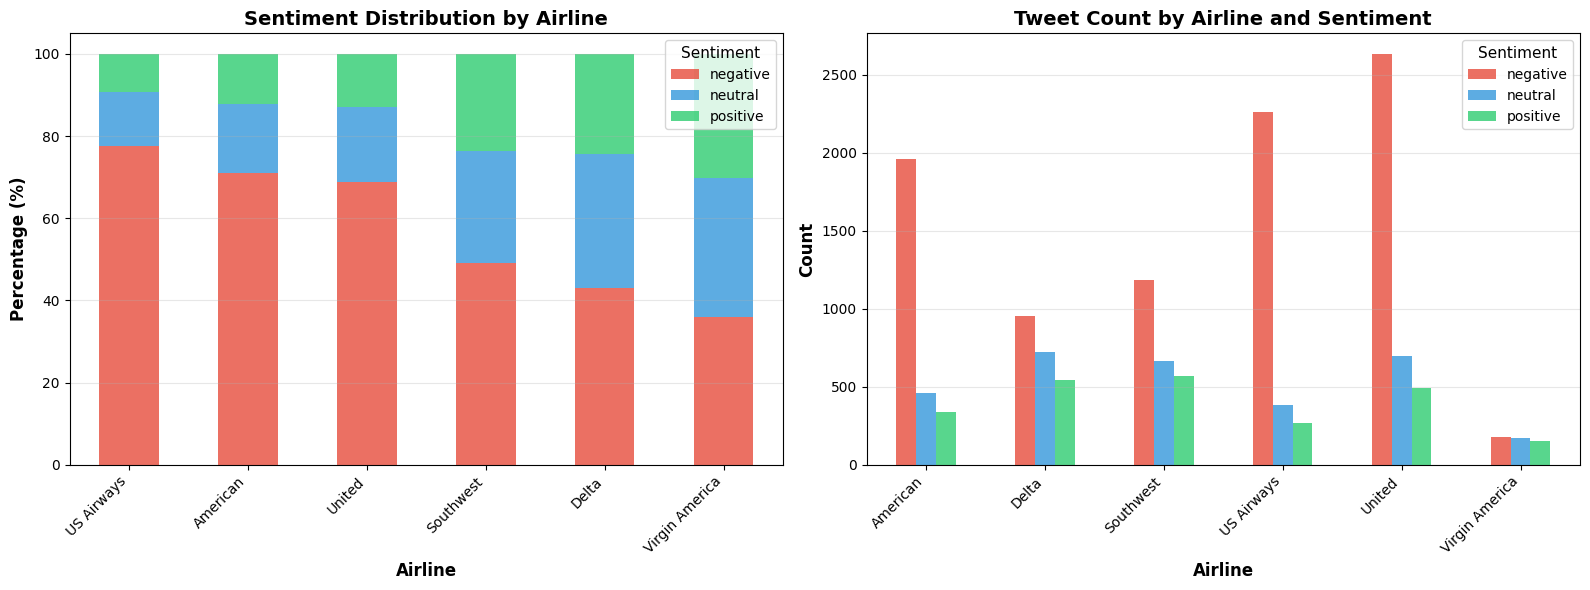

In [83]:
# Visualize airline-specific sentiment
vai.visualize_airline_sentiment(df)

In [84]:
# Analyze text characteristics
vai.print_text_statistics(df)

TEXT STATISTICS

 Text Length Statistics:
Mean: 103.82 characters
Median: 114.00 characters
Min: 12 characters
Max: 186 characters
Std Dev: 36.28 characters

 Word Count Statistics:
Mean: 17.65 words
Median: 19.00 words
Min: 2 words
Max: 36 words

 Content Features:
Tweets with URLs: 1,173 (8.01%)
Tweets with Mentions: 14,640 (100.00%)
Tweets with Hashtags: 2,489 (17.00%)
Average Exclamation Marks: 0.36
Average Question Marks: 0.32

Text Length by Sentiment:
neutral   :  87.36 chars, 14.41 words
positive  :  86.08 chars, 14.01 words
negative  : 113.95 chars, 19.69 words


In [85]:
# Sample tweets from each sentiment category
vai.sample_tweets_by_sentiment(df, n_samples=3)

SAMPLE TWEETS BY SENTIMENT
POSITIVE TWEETS

1. Airline: Southwest | Confidence: 1.0
   Tweet: @SouthwestAir thanks for your excellent response time and assistance! All set :)

2. Airline: Delta | Confidence: 1.0
   Tweet: @JetBlue thanks. I appreciate your prompt response.

3. Airline: Delta | Confidence: 1.0
   Tweet: @JetBlue yes, with about 20 minutes to spare.  FYI - your employees are amazing.  Keep up the good work!
NEUTRAL TWEETS

1. Airline: United | Confidence: 0.3512
   Tweet: @united we finally just arrive to Bogota, good but long flight!!

2. Airline: American | Confidence: 0.6452
   Tweet: @AmericanAir got a callback at 1 am, took care of it. thanks.

3. Airline: Delta | Confidence: 1.0
   Tweet: @JetBlue is there wifi on he plain
NEGATIVE TWEETS

1. Airline: United | Confidence: 1.0
   Tweet: @united gate C 24 IAD. U released passengers to board w/others deplaning .50 peopleOn bridge while next flight  board http://t.co/HfoF33iyhi

2. Airline: US Airways | Confidence: 0.6

In [86]:
# Split data into train/validation/test sets
train_df, val_df, test_df = vai.split_train_val_test(
    df,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    stratify_column='airline_sentiment',
    random_state=42
)

print(f"\nData Split Summary:")
print(f"  • Training:   {len(train_df):6,} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"  • Validation: {len(val_df):6,} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"  • Test:       {len(test_df):6,} samples ({len(test_df)/len(df)*100:.1f}%)")

Training set:   10,248 records (70.0%)
Validation set:  2,196 records (15.0%)
Test set:        2,196 records (15.0%)

  Sentiment distribution verification:
   Train: positive: 16.15%  neutral: 21.17%  negative: 62.69%     Val  : positive: 16.12%  neutral: 21.17%  negative: 62.70%     Test : positive: 16.12%  neutral: 21.17%  negative: 62.70%  
Data Split Summary:
  • Training:   10,248 samples (70.0%)
  • Validation:  2,196 samples (15.0%)
  • Test:        2,196 samples (15.0%)


In [87]:
# Prepare data in Vertex AI format (JSONL)
train_jsonl = vai.prepare_data_for_vertex_ai(
    train_df,
    text_column='text',
    label_column='airline_sentiment',
    output_path=f'{PROCESSED_DATA_DIR}/train_data.jsonl'
)

val_jsonl = vai.prepare_data_for_vertex_ai(
    val_df,
    text_column='text',
    label_column='airline_sentiment',
    output_path=f'{PROCESSED_DATA_DIR}/val_data.jsonl'
)

test_jsonl = vai.prepare_data_for_vertex_ai(
    test_df,
    text_column='text',
    label_column='airline_sentiment',
    output_path=f'{PROCESSED_DATA_DIR}/test_data.jsonl'
)

Saved to: Data/processed/train_data.jsonl
Saved to: Data/processed/val_data.jsonl
Saved to: Data/processed/test_data.jsonl


## Model Training with Twitter-RoBERTa

In [88]:
# Model training imports
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from datasets import Dataset
from sklearn.metrics import classification_report, confusion_matrix, f1_score

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
print(f"Using model: {MODEL_NAME}")

Using model: cardiffnlp/twitter-roberta-base-sentiment-latest


In [89]:
# Load preprocessed data
train_df_processed = pd.read_csv('Data/processed/train_preprocessed.csv')
val_df_processed = pd.read_csv('Data/processed/val_preprocessed.csv')
test_df_processed = pd.read_csv('Data/processed/test_preprocessed.csv')

# CRITICAL FIX: Remove rows with null text_processed values
print(f"Before removing nulls - Train: {len(train_df_processed)}, Val: {len(val_df_processed)}, Test: {len(test_df_processed)}")
print(f"Null values - Train: {train_df_processed['text_processed'].isnull().sum()}, Val: {val_df_processed['text_processed'].isnull().sum()}, Test: {test_df_processed['text_processed'].isnull().sum()}")

train_df_processed = train_df_processed.dropna(subset=['text_processed']).reset_index(drop=True)
val_df_processed = val_df_processed.dropna(subset=['text_processed']).reset_index(drop=True)
test_df_processed = test_df_processed.dropna(subset=['text_processed']).reset_index(drop=True)

# Fill any remaining empty strings
train_df_processed['text_processed'] = train_df_processed['text_processed'].fillna('').astype(str)
val_df_processed['text_processed'] = val_df_processed['text_processed'].fillna('').astype(str)
test_df_processed['text_processed'] = test_df_processed['text_processed'].fillna('').astype(str)

print(f"After cleaning - Train: {len(train_df_processed)}, Val: {len(val_df_processed)}, Test: {len(test_df_processed)}")

# Label mapping
label2id = {'positive': 0, 'neutral': 1, 'negative': 2}
id2label = {0: 'positive', 1: 'neutral', 2: 'negative'}

train_df_processed['label'] = train_df_processed['airline_sentiment'].map(label2id)
val_df_processed['label'] = val_df_processed['airline_sentiment'].map(label2id)
test_df_processed['label'] = test_df_processed['airline_sentiment'].map(label2id)

print(f"\nFinal dataset sizes with labels:")
print(f"Train: {len(train_df_processed)}, Val: {len(val_df_processed)}, Test: {len(test_df_processed)}")

Before removing nulls - Train: 10248, Val: 2196, Test: 2196
Null values - Train: 9, Val: 3, Test: 5
After cleaning - Train: 10239, Val: 2193, Test: 2191

Final dataset sizes with labels:
Train: 10239, Val: 2193, Test: 2191


In [90]:
# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

print("Model loaded")

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Model loaded


In [91]:
# Tokenize datasets
def tokenize_function(examples):
    return tokenizer(examples['text_processed'], truncation=True, max_length=128, padding=False)

train_dataset = Dataset.from_pandas(train_df_processed[['text_processed', 'label']])
val_dataset = Dataset.from_pandas(val_df_processed[['text_processed', 'label']])
test_dataset = Dataset.from_pandas(test_df_processed[['text_processed', 'label']])

# Remove __index_level_0__ column that pandas adds
train_dataset = train_dataset.remove_columns(['__index_level_0__']) if '__index_level_0__' in train_dataset.column_names else train_dataset
val_dataset = val_dataset.remove_columns(['__index_level_0__']) if '__index_level_0__' in val_dataset.column_names else val_dataset
test_dataset = test_dataset.remove_columns(['__index_level_0__']) if '__index_level_0__' in test_dataset.column_names else test_dataset

train_dataset = train_dataset.map(tokenize_function, batched=True, remove_columns=['text_processed'])
val_dataset = val_dataset.map(tokenize_function, batched=True, remove_columns=['text_processed'])
test_dataset = test_dataset.map(tokenize_function, batched=True, remove_columns=['text_processed'])

print("Tokenization complete")

Map:   0%|          | 0/10239 [00:00<?, ? examples/s]

Map:   0%|          | 0/2193 [00:00<?, ? examples/s]

Map:   0%|          | 0/2191 [00:00<?, ? examples/s]

Tokenization complete


In [92]:
# Training configuration
training_args = TrainingArguments(
    output_dir='Data/models/roberta-twitter',
    num_train_epochs=4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',  # Fixed: was 'evaluation_strategy' in older versions
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=100,
    save_total_limit=2,
    fp16=torch.cuda.is_available()
)

print("Training config set")

Training config set


In [93]:
# Compute metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    f1_macro = f1_score(labels, predictions, average='macro')
    f1_weighted = f1_score(labels, predictions, average='weighted')
    return {'f1_macro': f1_macro, 'f1_weighted': f1_weighted}

# Create trainer
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer initialized")

/var/folders/kt/8p_wk1zn6_dc1bvrf6rr0tnw0000gn/T/ipykernel_51682/3556036655.py:11: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Trainer initialized


In [94]:
# Train model
print("Training...")
train_result = trainer.train()
print(f"Training complete! Loss: {train_result.training_loss:.4f}")

Training...


/Users/bala/src/umd_classes/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.488000,0.464184,0.762195,0.815869
2,0.391000,0.456337,0.777104,0.828016
3,0.295200,0.481096,0.792704,0.837342
4,0.226200,0.518364,0.789758,0.835544


/Users/bala/src/umd_classes/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/bala/src/umd_classes/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/bala/src/umd_classes/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Training complete! Loss: 0.4074


## Model Evaluation

In [95]:
# Evaluate on test set
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_df_processed['label'].values

# Calculate F1 scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"F1-Score (Macro): {f1_macro:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")

/Users/bala/src/umd_classes/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


F1-Score (Macro): 0.7861
F1-Score (Weighted): 0.8334


In [96]:
# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=['positive', 'neutral', 'negative'],
    digits=4
))


Classification Report:
              precision    recall  f1-score   support

    positive     0.7705    0.7684    0.7694       354
     neutral     0.6829    0.6991    0.6909       462
    negative     0.9011    0.8945    0.8978      1375

    accuracy                         0.8330      2191
   macro avg     0.7848    0.7873    0.7861      2191
weighted avg     0.8340    0.8330    0.8334      2191



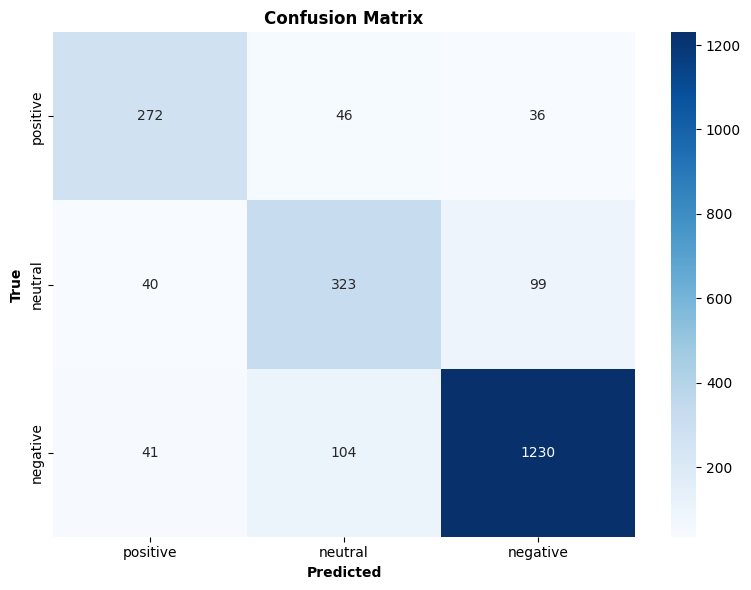

In [97]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['positive', 'neutral', 'negative'],
            yticklabels=['positive', 'neutral', 'negative'])
plt.title('Confusion Matrix', fontweight='bold')
plt.ylabel('True', fontweight='bold')
plt.xlabel('Predicted', fontweight='bold')
plt.tight_layout()
plt.savefig('Data/processed/figures/confusion_matrix.png', dpi=300)
plt.show()

## Bonus: BERT Comparison

In [98]:
# Train BERT baseline
bert_model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)
bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

print("BERT baseline loaded")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BERT baseline loaded


In [99]:
# Tokenize for BERT - create fresh datasets from dataframes
def bert_tokenize(examples):
    return bert_tokenizer(examples['text_processed'], truncation=True, max_length=128, padding=False)

# Create fresh datasets for BERT from the preprocessed dataframes
bert_train_dataset = Dataset.from_pandas(train_df_processed[['text_processed', 'label']])
bert_val_dataset = Dataset.from_pandas(val_df_processed[['text_processed', 'label']])
bert_test_dataset = Dataset.from_pandas(test_df_processed[['text_processed', 'label']])

# Remove pandas index column
bert_train_dataset = bert_train_dataset.remove_columns(['__index_level_0__']) if '__index_level_0__' in bert_train_dataset.column_names else bert_train_dataset
bert_val_dataset = bert_val_dataset.remove_columns(['__index_level_0__']) if '__index_level_0__' in bert_val_dataset.column_names else bert_val_dataset
bert_test_dataset = bert_test_dataset.remove_columns(['__index_level_0__']) if '__index_level_0__' in bert_test_dataset.column_names else bert_test_dataset

# Apply BERT tokenization
bert_train = bert_train_dataset.map(bert_tokenize, batched=True, remove_columns=['text_processed'])
bert_val = bert_val_dataset.map(bert_tokenize, batched=True, remove_columns=['text_processed'])
bert_test = bert_test_dataset.map(bert_tokenize, batched=True, remove_columns=['text_processed'])

bert_trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=bert_train,
    eval_dataset=bert_val,
    tokenizer=bert_tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=bert_tokenizer),
    compute_metrics=compute_metrics
)

print("BERT trainer ready")

Map:   0%|          | 0/10239 [00:00<?, ? examples/s]

Map:   0%|          | 0/2193 [00:00<?, ? examples/s]

Map:   0%|          | 0/2191 [00:00<?, ? examples/s]

/var/folders/kt/8p_wk1zn6_dc1bvrf6rr0tnw0000gn/T/ipykernel_51682/983950035.py:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  bert_trainer = Trainer(


BERT trainer ready


In [100]:
# Train BERT
print("Training BERT baseline...")
bert_result = bert_trainer.train()
print(f"BERT training complete! Loss: {bert_result.training_loss:.4f}")

Training BERT baseline...


/Users/bala/src/umd_classes/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.534600,0.507330,0.743471,0.802514
2,0.416300,0.460008,0.771846,0.824071
3,0.297800,0.505923,0.771815,0.820878
4,0.221900,0.528817,0.773083,0.822345


/Users/bala/src/umd_classes/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/bala/src/umd_classes/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/bala/src/umd_classes/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


BERT training complete! Loss: 0.4024


In [101]:
# Evaluate BERT
bert_preds = bert_trainer.predict(bert_test)
bert_y_pred = np.argmax(bert_preds.predictions, axis=1)

bert_f1_macro = f1_score(y_true, bert_y_pred, average='macro')
bert_f1_weighted = f1_score(y_true, bert_y_pred, average='weighted')

print(f"BERT F1-Macro: {bert_f1_macro:.4f}")
print(f"BERT F1-Weighted: {bert_f1_weighted:.4f}")

/Users/bala/src/umd_classes/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


BERT F1-Macro: 0.7668
BERT F1-Weighted: 0.8195


In [102]:
# Model comparison
comparison = pd.DataFrame({
    'Model': ['BERT', 'Twitter-RoBERTa'],
    'F1-Macro': [bert_f1_macro, f1_macro],
    'F1-Weighted': [bert_f1_weighted, f1_weighted]
})

print("\nModel Comparison:")
print(comparison.to_string(index=False))
print(f"\nImprovement: +{(f1_macro - bert_f1_macro):.4f} ({(f1_macro - bert_f1_macro)/bert_f1_macro*100:.2f}%)")


Model Comparison:
          Model  F1-Macro  F1-Weighted
           BERT  0.766844     0.819512
Twitter-RoBERTa  0.786056     0.833443

Improvement: +0.0192 (2.51%)


## Bonus: Dashboard Visualization

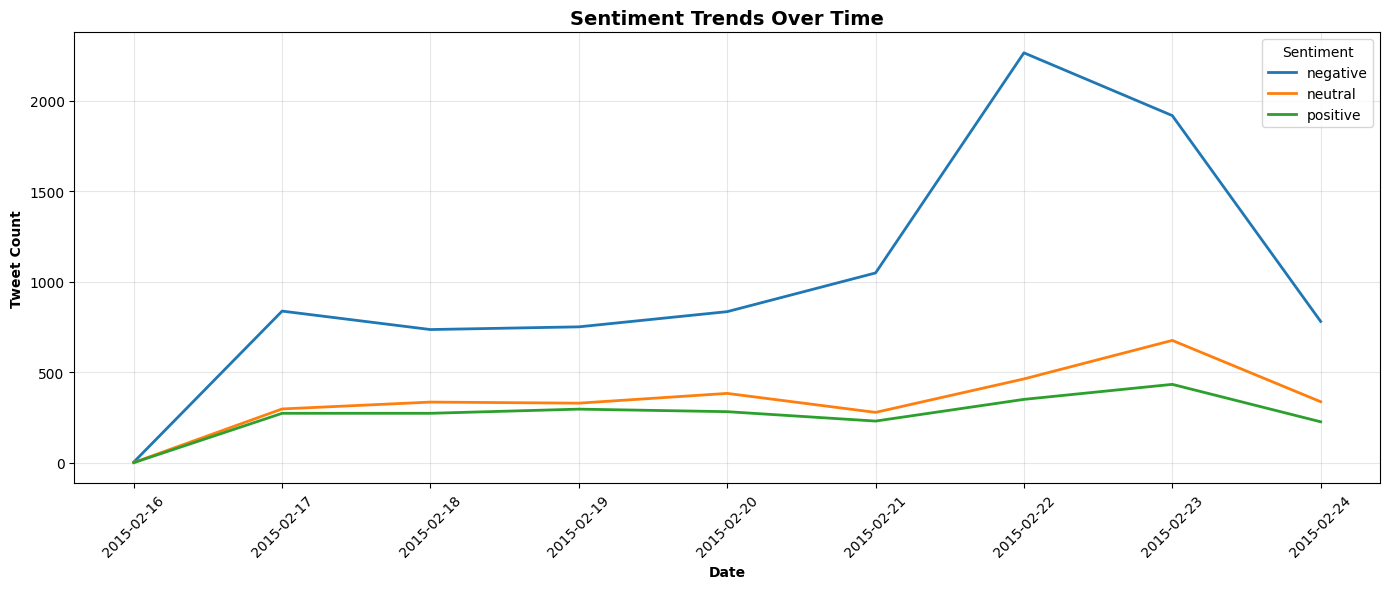

In [103]:
# Sentiment trends over time
df['tweet_created'] = pd.to_datetime(df['tweet_created'])
df['date'] = df['tweet_created'].dt.date

daily_sentiment = df.groupby(['date', 'airline_sentiment']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
daily_sentiment.plot(ax=ax, linewidth=2)
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Tweet Count', fontweight='bold')
ax.set_title('Sentiment Trends Over Time', fontweight='bold', fontsize=14)
ax.legend(title='Sentiment')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Data/processed/figures/sentiment_trends.png', dpi=300)
plt.show()